In [ ]:
!pip install prophet

In [1]:
!unzip dataset_d3_filtrado.zip

Archive:  dataset_d3_filtrado.zip
  inflating: dataset_d3_filtrado.csv  


DEBUG:cmdstanpy:input tempfile: /tmp/tmp80ax3m9j/lw27g7pf.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp80ax3m9j/lqymui4o.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=36437', 'data', 'file=/tmp/tmp80ax3m9j/lw27g7pf.json', 'init=/tmp/tmp80ax3m9j/lqymui4o.json', 'output', 'file=/tmp/tmp80ax3m9j/prophet_modeln60ky7iu/prophet_model-20250331215635.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
21:56:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
21:56:41 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


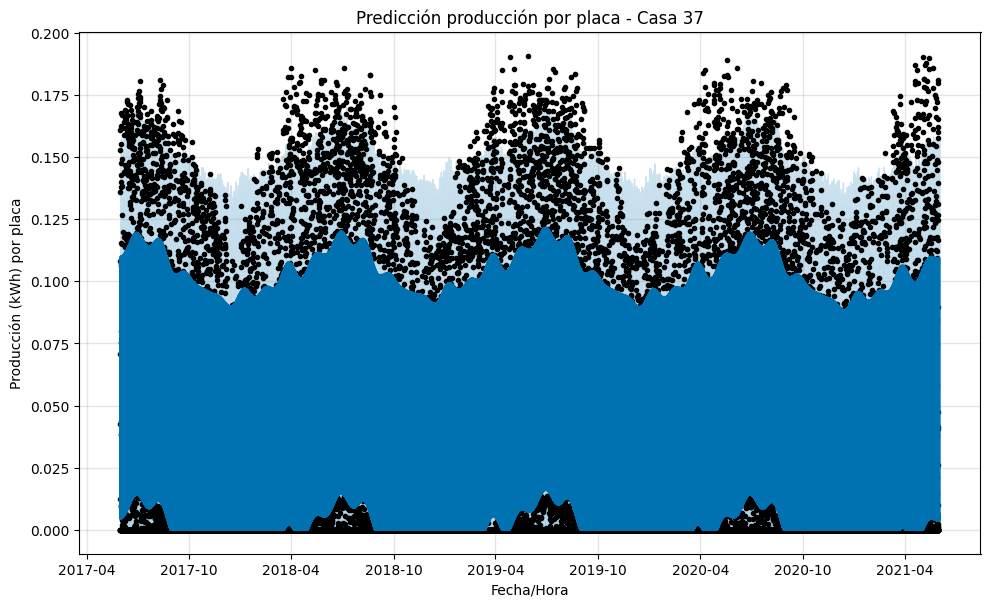

DEBUG:cmdstanpy:input tempfile: /tmp/tmp80ax3m9j/f6m2f60u.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp80ax3m9j/tnv3ia1n.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=43183', 'data', 'file=/tmp/tmp80ax3m9j/f6m2f60u.json', 'init=/tmp/tmp80ax3m9j/tnv3ia1n.json', 'output', 'file=/tmp/tmp80ax3m9j/prophet_model9gberwon/prophet_model-20250331215649.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
21:56:49 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
21:56:54 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(
DEBUG:cmdstanpy:input tempfile: /tmp/tmp80ax3m9j/lb


Predicciones recientes por casa:

Casa 37:
                       ds      yhat  yhat_lower  yhat_upper
35107 2021-06-01 20:00:00  0.005241         0.0    0.050523
35108 2021-06-01 21:00:00  0.007059         0.0    0.053362
35109 2021-06-01 22:00:00  0.006719         0.0    0.052621
35110 2021-06-01 23:00:00  0.005024         0.0    0.047199
35111 2021-06-02 00:00:00  0.004283         0.0    0.049985

Casa 638:
                       ds      yhat  yhat_lower  yhat_upper
35131 2021-06-01 20:00:00  0.005019         0.0    0.050302
35132 2021-06-01 21:00:00  0.006837         0.0    0.050824
35133 2021-06-01 22:00:00  0.006501         0.0    0.054843
35134 2021-06-01 23:00:00  0.004810         0.0    0.051972
35135 2021-06-02 00:00:00  0.004070         0.0    0.049895

Casa 741:
                       ds      yhat  yhat_lower  yhat_upper
34435 2021-06-01 20:00:00  0.005237         0.0    0.052091
34436 2021-06-01 21:00:00  0.007043         0.0    0.048266
34437 2021-06-01 22:00:00  0.00667

In [2]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt

# 1) CARGA DE DATOS
file_path = "dataset_d3_filtrado.csv"
df = pd.read_csv(file_path)
df['datetime'] = pd.to_datetime(df['datetime'])

# 2) FILTRADO Y NORMALIZACIÓN
df = df[df['num_placas'] > 0]
df['produccion_por_placa'] = df['produccion_kWh'] / df['num_placas']
df.sort_values(by='datetime', inplace=True)

# 3) AGRUPACIÓN POR CASA Y HORA
df_grouped = (
    df.groupby(['id_casa', 'datetime'], as_index=False)
      .agg({'produccion_por_placa': 'mean'})
)

# 4) MODELADO Y PREDICCIÓN POR CADA CASA
resultados_por_casa = {}

casas_unicas = df_grouped['id_casa'].unique()

for casa_id in casas_unicas:
    df_casa = df_grouped[df_grouped['id_casa'] == casa_id].copy()
    df_casa.rename(columns={'datetime': 'ds', 'produccion_por_placa': 'y'}, inplace=True)

    modelo = Prophet(
        daily_seasonality=True,
        weekly_seasonality=False,
        yearly_seasonality=True,
        seasonality_mode='additive',
        changepoint_prior_scale=0.1,
        seasonality_prior_scale=10,
        interval_width=0.90
    )

    try:
        modelo.fit(df_casa)
        future = modelo.make_future_dataframe(periods=48, freq='H')
        forecast = modelo.predict(future)
        forecast['yhat'] = forecast['yhat'].clip(lower=0)
        forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
        forecast['yhat_upper'] = forecast['yhat_upper'].clip(lower=0)

        resultados_por_casa[casa_id] = {
            'modelo': modelo,
            'forecast': forecast,
            'datos_entrenamiento': df_casa
        }

        if casa_id == casas_unicas[0]:
            fig = modelo.plot(forecast)
            plt.title(f"Predicción producción por placa - Casa {casa_id}")
            plt.xlabel("Fecha/Hora")
            plt.ylabel("Producción (kWh) por placa")
            plt.grid(True)
            plt.show()

    except Exception as e:
        print(f"Error al procesar casa {casa_id}: {e}")

# 5) IMPRIMIR ALGUNOS RESULTADOS
print("\nPredicciones recientes por casa:")
for casa_id, datos in resultados_por_casa.items():
    print(f"\nCasa {casa_id}:")
    print(datos['forecast'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5))


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


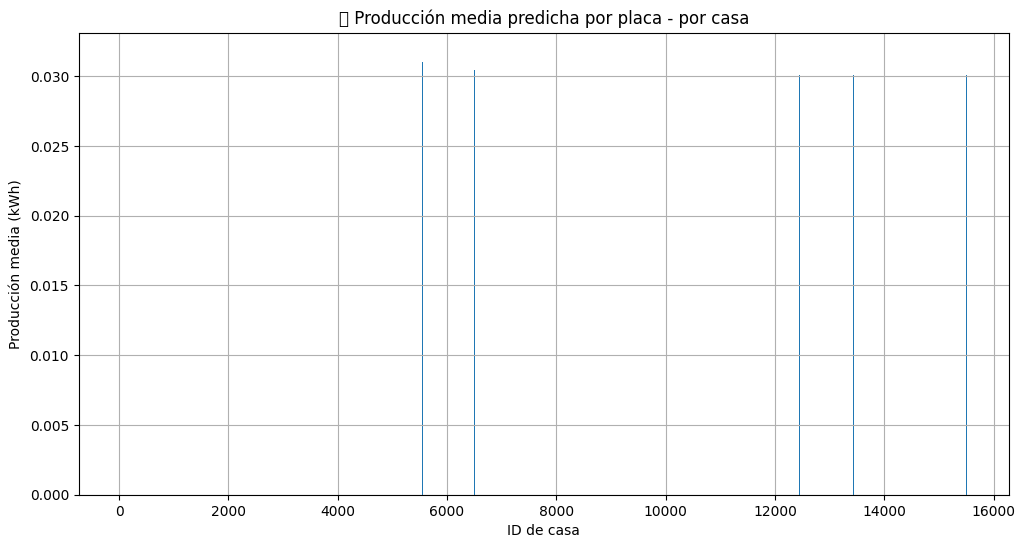

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


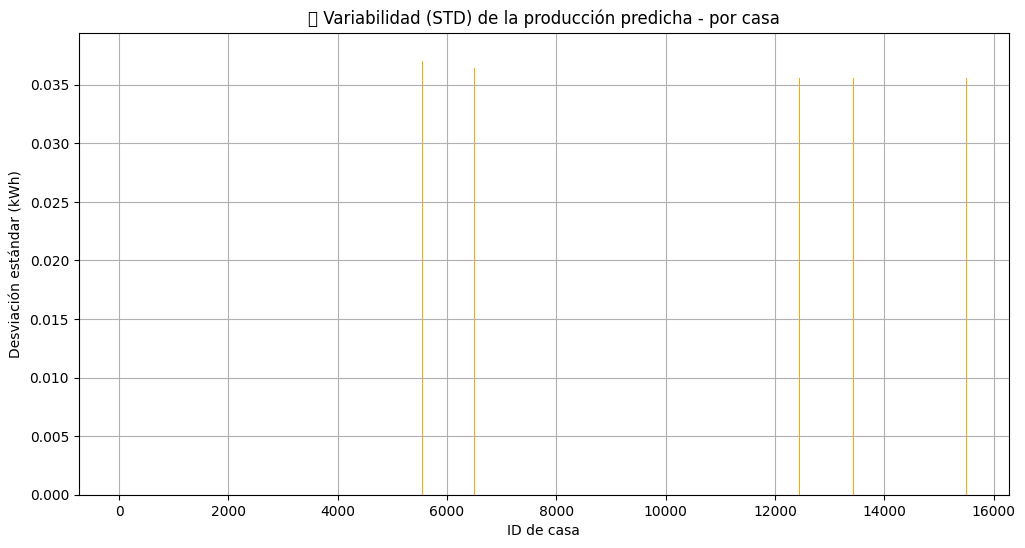

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)



🏠 Casas con menor producción promedio esperada:
Casa 1794: 0.030 kWh
Casa 6386: 0.030 kWh
Casa 6661: 0.030 kWh
Casa 14024: 0.030 kWh
Casa 12657: 0.030 kWh


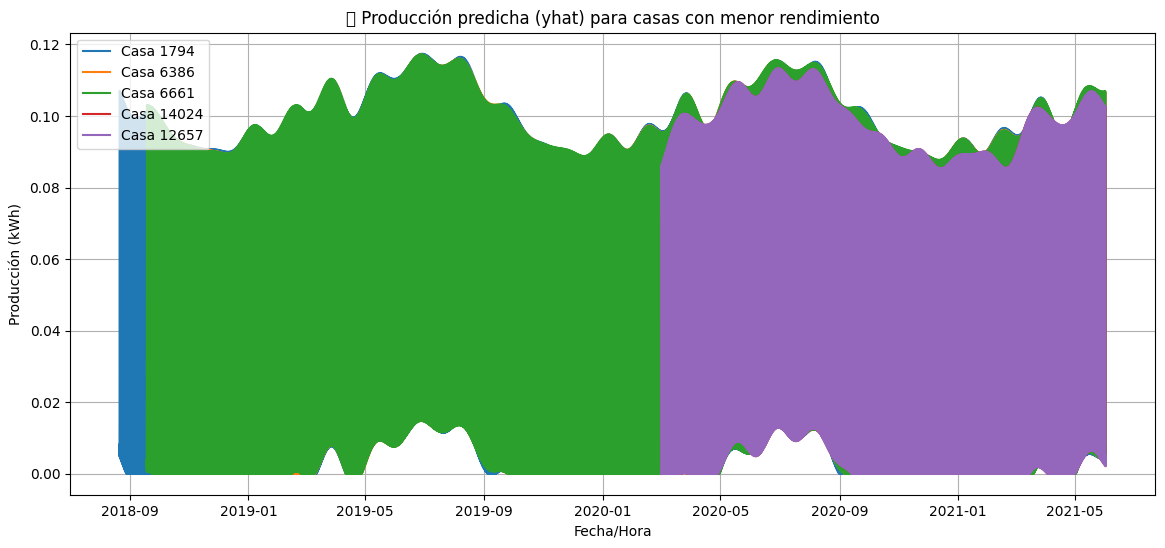

In [3]:
import matplotlib.pyplot as plt

# 1) PRODUCCIÓN MEDIA PREDICHA POR CASA
media_predicha = {
    casa_id: datos['forecast']['yhat'].mean()
    for casa_id, datos in resultados_por_casa.items()
}

plt.figure(figsize=(12, 6))
plt.bar(media_predicha.keys(), media_predicha.values())
plt.title("📈 Producción media predicha por placa - por casa")
plt.xlabel("ID de casa")
plt.ylabel("Producción media (kWh)")
plt.grid(True)
plt.show()

# 2) VARIABILIDAD DE PRODUCCIÓN (DESVIACIÓN ESTÁNDAR)
variabilidad_predicha = {
    casa_id: datos['forecast']['yhat'].std()
    for casa_id, datos in resultados_por_casa.items()
}

plt.figure(figsize=(12, 6))
plt.bar(variabilidad_predicha.keys(), variabilidad_predicha.values(), color='orange')
plt.title("📊 Variabilidad (STD) de la producción predicha - por casa")
plt.xlabel("ID de casa")
plt.ylabel("Desviación estándar (kWh)")
plt.grid(True)
plt.show()

# 3) TOP 5 CASAS CON MENOR PRODUCCIÓN PROMEDIO
casas_menor_prod = sorted(media_predicha.items(), key=lambda x: x[1])[:5]
print("\n🏠 Casas con menor producción promedio esperada:")
for casa_id, promedio in casas_menor_prod:
    print(f"Casa {casa_id}: {promedio:.3f} kWh")

# 4) CURVAS SUPERPUESTAS DE PRODUCCIÓN DE ALGUNAS CASAS
casas_a_comparar = [item[0] for item in casas_menor_prod]  # Por ejemplo, las 5 con menor producción

plt.figure(figsize=(14, 6))
for casa_id in casas_a_comparar:
    forecast = resultados_por_casa[casa_id]['forecast']
    plt.plot(forecast['ds'], forecast['yhat'], label=f'Casa {casa_id}')

plt.title("📆 Producción predicha (yhat) para casas con menor rendimiento")
plt.xlabel("Fecha/Hora")
plt.ylabel("Producción (kWh)")
plt.legend()
plt.grid(True)
plt.show()
